In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, append = True)
import time

import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import numpy as np 

from tenpy.models.model import CouplingMPOModel, NearestNeighborModel
from tenpy.models.lattice import Chain
from tenpy.networks.site import SpinHalfSite, SpinHalfFermionSite, set_common_charges, GroupedSite

from fisher_lg.Kondo import KondoChain, KondoModel
from fisher_lg.State import State_Evo

from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain
from tenpy.algorithms import dmrg, tebd
from tenpy.networks.mpo import MPO


The bellow is a class constructed for the TFIM which is featured on the TeNPy website

In [5]:
model_params = {
    'J_ei': -10 , 'J_ii': -0.1,  
    't' : 1,
    'L': 4,
    'symmetry_breaking_field' : 1.e-6,
    'bc': 'finite',
    'model_type' : "Kondo",
    'conserve' : 'Sz'
}
extra_params = {
    'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 60,
    'max_trunc_err' : 1e-8,
    'trunc_params': {
        'chi_max':  300,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-8
    },
    'verbose': False,
    'combine': True, #tebd params 
    'N_times' : 4,  #Only even N_times are used for K, 
    'dt': 0.02,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 3  #only an option for calculating the maximum of the LG correlator
}
psi_first = State_Evo.from_dmrg_search_Sz(model_params, extra_params)
psi1= psi_first.copy()
energy = psi_first.energy
energy1 = energy
deg_list = []
engy_list = []
sz_list = []

while np.abs(energy - energy1) < 5.e-3:
    
    deg_list += [psi1]
    engy_list += [energy1]
    sz_list += [round(np.mean(psi1.expectation_value('Sigmazi')), 4)]

    eng = dmrg.TwoSiteDMRGEngine(psi_first.copy(), psi_first.model, extra_params)
    eng.init_env(orthogonal_to = deg_list)
    energy1, psi1 = eng.run()
    
print( len(deg_list), sz_list , engy_list)


    

1 [np.float64(1.0)] [np.float64(-40.30000400000001)]


In [148]:
psiw = State_Evo.from_dmrg_search_Sz(model_params = model_params, dmrg_params = extra_params)

start_time = time.perf_counter()
psi.calculate_QtQ('Sigmazi', op_sum = False)
end_time = time.perf_counter()

print(end_time - start_time, psiw.energy, psi.model_type)


2.6904673999524675 -4.54724215387448 Kondo


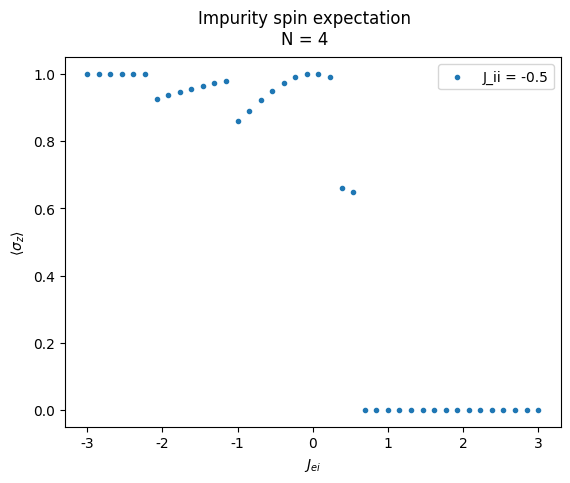

In [2]:
L = 4
chi_max = int( min(8 ** (L/2), 300))
op = 'Sigmazi'
op_sum = True
num_points = 40
t_end = 10
dt = 0.02

fig, ax = plt.subplots(1)

extra_params = {
   'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 30,
    'max_trunc_err' : 1e-6,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-6
    },
    'verbose': False,
    'combine': True,
    'N_times' : 2,  #Only even N_times are used for K,
    'dt': dt,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : t_end,  #only an option for calculating the maximum of the LG correlator
}

jei_range = np.linspace(-3, 3, num_points)
jii_range = [-0.5] #[-.1, -.5, -1, -2]

psi_init = None

for j_ii in jii_range:
    expe = []
    expe1 = []
    for j_ei in jei_range:
        model_params = {
            'J_ei': j_ei , 'J_ii': j_ii,  
            't' : 1.0,
            'L': L,
            'bc_MPS': 'finite',
            'model_type' : "Kondo",
            'conserve' : 'Sz',
            'symmetry_breaking_field' : 1.e-5}

        psi_b = State_Evo.from_dmrg_search_Sz(model_params, extra_params)
        expe1 += [np.mean(psi_b.expectation_value(op))]


    ax.scatter(jei_range, expe1, marker = '.', label = "J_ii = " + str(j_ii), zorder = 3)


fig.suptitle("Impurity spin expectation\nN = " + str(L))
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("$J_{ei}$")
ax.set(ylabel = "$\\langle \\sigma_z \\rangle$")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()



final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=2.83e-05


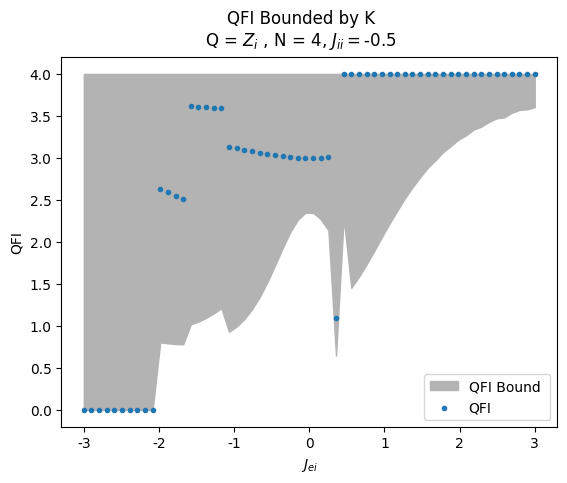

In [ ]:
L = 4
chi_max = int( min(8 ** (L/2), 300))
op = 'Sigmazi'
op_sum = False
num_points = 60
t_end = .5
dt = 0.01
j_ii = -.5

extra_params = {
    'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 30,
    'max_trunc_err' : 1e-6,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-6
    },
    'verbose': False,
    'combine': True,
    'N_times' : 2,  #Only even N_times are used for K,
    'dt': dt,'N_steps': 1,
    'order': 2,
    'start_time' : 0  ,
    't_max' : t_end,  #only an option for calculating the maximum of the LG correlator
}


theta_range = np.linspace(-3, 3, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI_lst =[]
for theta in theta_range:
    model_params = {
    'J_ei':  theta , 'J_ii': j_ii,  #J_ei =1   J_ii pm,  J_ei=-1   J_ii pm
    't' : 1.0,
    'L': L,
    'bc_MPS': 'finite',
    'model_type' : "Kondo",
    'conserve' : None,
    'symmetry_breaking_field' : 1.e-7} #conserve = None when not using from_dmrg_search_Sz

    psi = State_Evo.from_dmrg(model_params, extra_params)
    t_max, LG_max , qfi = psi.calculate_LG_bound(op, op_sum = op_sum, return_QFI= True)
    LG_bound += [LG_max]
    QFI_lst += [qfi]

ax.fill_between(theta_range, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range, QFI_lst, marker = '.', label = "QFI", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = $Z_i$ , N = " + str(L) + ", $J_{ii}= $" + str(j_ii))
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("$J_{ei}$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

In [391]:
model_params = {
    'J_ei':  -0.5 , 'J_ii': -0.5,  #J_ei =1   J_ii pm,  J_ei=-1   J_ii pm
    't' : 1.0,
    'L': 4,
    'bc_MPS': 'finite',
    'model_type' : "Kondo",
    'conserve' : None}

state_Sz0 = ["down_e up_i"]    # electron site, impurity site
state_SzMax = ["up_e up_i"]   # electron site, impurity site

chain = KondoChain(model_params).lat.mps_sites()
MPS_Sz0 = MPS.from_product_state(chain, state_Sz0 * L)
MPS_SzMax = MPS.from_product_state(chain, state_SzMax * L)


psi = State_Evo.from_dmrg(model_params, extra_params, initial_state = MPS_Sz0)
t_max, LG_max , qfi = psi.calculate_LG_bound(op, op_sum = op_sum, return_QFI= True)
print( "initial_state:", state_Sz0, "energy: ", psi.energy, "LG_max: ", LG_max, "qfi: ", qfi)

psi = State_Evo.from_dmrg(model_params, extra_params, initial_state = MPS_SzMax)
t_max, LG_max , qfi = psi.calculate_LG_bound(op, op_sum = op_sum, return_QFI= True)
print( "initial_state:", state_SzMax, "energy: ", psi.energy, "LG_max: ", LG_max, "qfi: ", qfi)
 

initial_state: ['down_e up_i'] energy:  -6.23190847270165 LG_max:  1.6310736825702836 qfi:  3.0360158644513633
initial_state: ['up_e up_i'] energy:  -6.231908472701654 LG_max:  0.10030856594007886 qfi:  0.1440633107352527


In [362]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\Kondo\\Kondo_L8_Jii-.5_Zi_QFI_Bound.png")

4.000000000000001


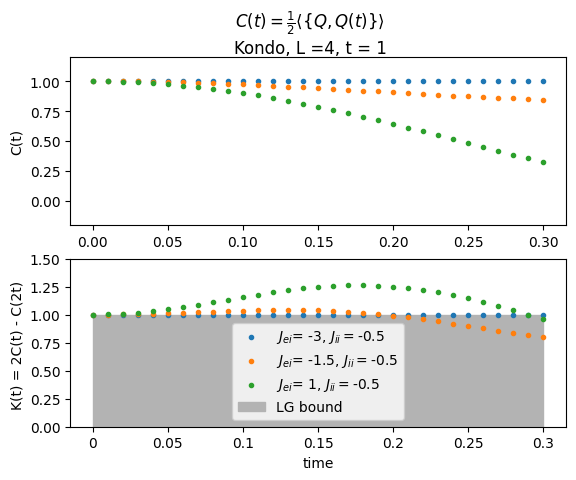

In [368]:
L = 4
chi_max = 220
op = 'Sigmazi'
op_sum = False
num_points = 30
t_end = .5
dt = 0.01
fig, ax = plt.subplots(2)

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 30,
    'max_trunc_err' : 1e-6,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-7
    },
    'verbose': False,
    'combine': True, #tebd params 
    'N_times' : num_points,
    'dt': dt,'N_steps': max(2*int( t_end//(2*dt * num_points)),1),
    'order': 2, 'start_time' : 0,
    't_max' : 30  #only an option for calculating the maximum of the LG correlator
    }
#[10, -.1], [5, -0.1], [1, -.1] t  = 3
Jg_lst = [ [-3, -.5], [-1.5, -.5], [1, -.5]]

for J_ei, J_ii in Jg_lst: 

    model_params = {
    'J_ei': J_ei , 'J_ii': J_ii,  
    't' : 1.0,
    'L': L,
    'bc_MPS': 'finite',
    'model_type' : "Kondo",
    'conserve' : None}

    psi = State_Evo.from_dmrg(model_params = model_params, dmrg_params = extra_params)
    
    times, Ct = psi.calculate_QtQ(op, op_sum = op_sum)
    ax[0].scatter(times, Ct, marker = '.', label = "$J_{ei} $= " + str(round(J_ei,2)) + ", $J_{ii}$ = " + str(round(J_ii,2)), zorder = 3)
    times, LG_correl, Kt = psi.calculate_LG_correlator(op, op_sum = op_sum)
    #ax[1].scatter(times, LG_correl, marker = '.', label = "$\\J = " + str(round(J_ei,2)) + ", h = " + str(round(J_ii,2)), zorder = 3)
    ax[1].scatter(times, Kt, marker = '.', label= "$J_{ei}$= " + str(round(J_ei,2)) + ", $J_{ii}=$" + str(round(J_ii,2)), zorder= 3)
ax[1].fill_between(times,-3, 1 ,  color = '.7', label = "LG bound "  )

print(psi.QFI(op, op_sum))

fig.suptitle("$C(t) = \\frac{1}{2}\\langle \\{Q, Q(t) \\}\\rangle$\nKondo, L =" + str(L) + ", t = 1")
ax[1].xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
#ax[1].set(ylabel = "2C(t) - C(2t) - C(0)")
ax[1].set(ylabel = "K(t) = 2C(t) - C(2t) ")
ax[0].set_ylim([-.2 ,1.2])
ax[1].set_ylim([0,1.5])
plt.legend()

plt.show()

In [ ]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\Kondo_L10_C_K.png")